In [32]:
import pandas as pd
import matplotlib.pyplot as plt
movies = pd.read_csv('dataset/movies.csv')
ratings = pd.read_csv('dataset/ratings.csv')
tags = pd.read_csv('dataset/tags.csv')

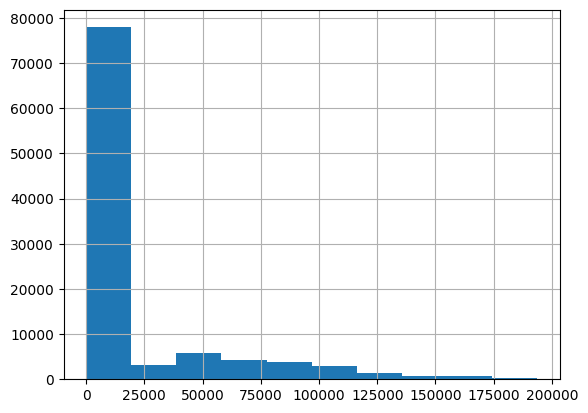

In [33]:
ratings['movieId'].hist()
plt.show()

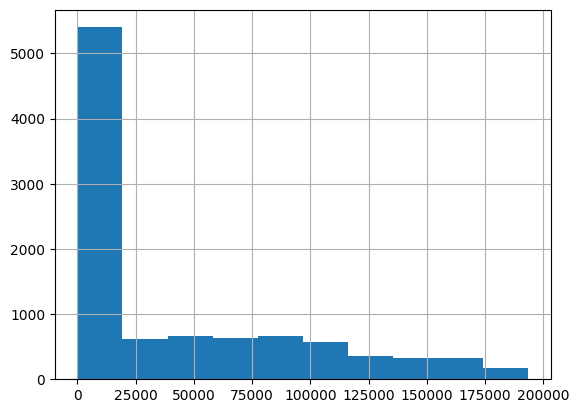

In [34]:
movies['movieId'].hist()
plt.show()

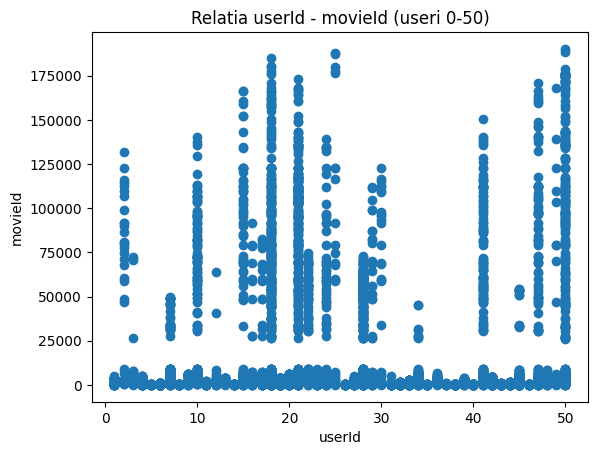

In [35]:
# relatie intre userId si movieId (doar userii 0-50)
subset = ratings[ratings['userId'] <= 50]
plt.scatter(subset['userId'], subset['movieId'])
plt.xlabel('userId')
plt.ylabel('movieId')
plt.title('Relatia userId - movieId (useri 0-50)')
plt.show()

In [36]:
print("Analiza movies:")
display(movies.shape)
display(movies.head())
display(movies.info())
display(movies.describe())
display(movies.isnull().sum())

Analiza movies:


(9742, 3)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


None

,movieId
count,9742.000000
mean,42200.353623
std,52160.494854
min,1.000000
25%,3248.250000
50%,7300.000000
75%,76232.000000
max,193609.000000


movieId    0
title      0
genres     0
dtype: int64

In [37]:
# Tratarea valorilor lipsa
# nr filme care in entitate genres au valoarea "no genres listed"
print((movies['genres'] == '(no genres listed)').sum())
# inlocuim valoarea "no genres listed" cu un string gol
movies['genres'] = movies['genres'].replace('(no genres listed)', '')

34


In [47]:
movies['genres_list'] = movies['genres'].apply(
    lambda x: x.split('|') if x != '' else []
)

# Extragere an din titlu
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
movies['title'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)

movies.head(5)

,movieId,title,genres,genres_list,year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0
1,2,Jumanji,Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]",1995.0
2,3,Grumpier Old Men,Comedy|Romance,"[Comedy, Romance]",1995.0
3,4,Waiting to Exhale,Comedy|Drama|Romance,"[Comedy, Drama, Romance]",1995.0
4,5,Father of the Bride Part II,Comedy,[Comedy],1995.0


In [39]:
#Ratings : conversie timestamp -> datetime
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
print("Ratings - timestamp to datetime")
display(ratings[['userId', 'movieId', 'rating', 'timestamp']].head())

Ratings - timestamp to datetime


,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


In [40]:
print("\nAnaliza ratings:")
display(ratings.shape)
display(ratings.head())
display(ratings.info())
display(ratings.describe())
display(ratings.isnull().sum())


Analiza ratings:


(100836, 4)

,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype        
---  ------     --------------   -----        
 0   userId     100836 non-null  int64        
 1   movieId    100836 non-null  int64        
 2   rating     100836 non-null  float64      
 3   timestamp  100836 non-null  datetime64[s]
dtypes: datetime64[s](1), float64(1), int64(2)
memory usage: 3.1 MB


None

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,100836
mean,326.127564,19435.295718,3.501557,2008-03-19 17:01:27
min,1.000000,1.000000,0.500000,1996-03-29 18:36:55
25%,177.000000,1199.000000,3.000000,2002-04-18 09:57:46
50%,325.000000,2991.000000,3.500000,2007-08-02 20:31:02
75%,477.000000,8122.000000,4.000000,2015-07-04 07:15:44
max,610.000000,193609.000000,5.000000,2018-09-24 14:27:30
std,182.618491,35530.987199,1.042529,NaN


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [41]:
# normalizare tag-uri(lowercase, whitespaces)
print("Exemple inainte de normalizare:")
display(tags['tag'].head(10))

tags['tag'] = tags['tag'].astype(str).str.lower().str.strip()

print("\nExemple dupa normalizare:")
display(tags['tag'].head(10))

Exemple inainte de normalizare:


0                funny
1      Highly quotable
2         will ferrell
3         Boxing story
4                  MMA
5            Tom Hardy
6                drugs
7    Leonardo DiCaprio
8      Martin Scorsese
9         way too long
Name: tag, dtype: str


Exemple dupa normalizare:


0                funny
1      highly quotable
2         will ferrell
3         boxing story
4                  mma
5            tom hardy
6                drugs
7    leonardo dicaprio
8      martin scorsese
9         way too long
Name: tag, dtype: str

In [42]:
# Tags : conversie timestamp -> datetime
tags['timestamp'] = pd.to_datetime(tags['timestamp'], unit='s')

print("\nTags - timestamp to datetime")
display(tags[['userId', 'movieId', 'tag', 'timestamp']].head())


Tags - timestamp to datetime


,userId,movieId,tag,timestamp
0,2,60756,funny,2015-10-24 19:29:54
1,2,60756,highly quotable,2015-10-24 19:29:56
2,2,60756,will ferrell,2015-10-24 19:29:52
3,2,89774,boxing story,2015-10-24 19:33:27
4,2,89774,mma,2015-10-24 19:33:20


In [43]:
print("\nAnaliza tags:")
display(tags.shape)
display(tags.head())
display(tags.info())
display(tags.describe())
display(tags.isnull().sum())
display(tags.duplicated().sum())


Analiza tags:


(3683, 4)

,userId,movieId,tag,timestamp
0,2,60756,funny,2015-10-24 19:29:54
1,2,60756,highly quotable,2015-10-24 19:29:56
2,2,60756,will ferrell,2015-10-24 19:29:52
3,2,89774,boxing story,2015-10-24 19:33:27
4,2,89774,mma,2015-10-24 19:33:20


<class 'pandas.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   userId     3683 non-null   int64        
 1   movieId    3683 non-null   int64        
 2   tag        3683 non-null   str          
 3   timestamp  3683 non-null   datetime64[s]
dtypes: datetime64[s](1), int64(2), str(1)
memory usage: 115.2 KB


None

,userId,movieId,timestamp
count,3683.000000,3683.000000,3683
mean,431.149335,27252.013576,2011-10-31 03:32:46
min,2.000000,1.000000,2006-01-13 19:09:12
25%,424.000000,1262.500000,2006-01-17 18:06:56
50%,474.000000,4454.000000,2010-03-29 03:16:04
75%,477.000000,39263.000000,2017-06-26 05:59:25
max,610.000000,193565.000000,2018-09-16 11:50:03
std,158.472553,43490.558803,NaN


userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

np.int64(0)

In [44]:
# Cati utilizatori unici
display(ratings['userId'].nunique())
# Cate filme unice au primit rating
display(ratings['movieId'].nunique())
# Distributia rating-urilor
display(ratings['rating'].describe())
display(ratings['rating'].value_counts().sort_index())
# Cate rating-uri a dat fiecare utilizator
display(ratings.groupby('userId')['rating'].count().describe())
# Cate rating-uri are fiecare film
display(ratings.groupby('movieId')['rating'].count().describe())

610

9724

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: rating, dtype: float64

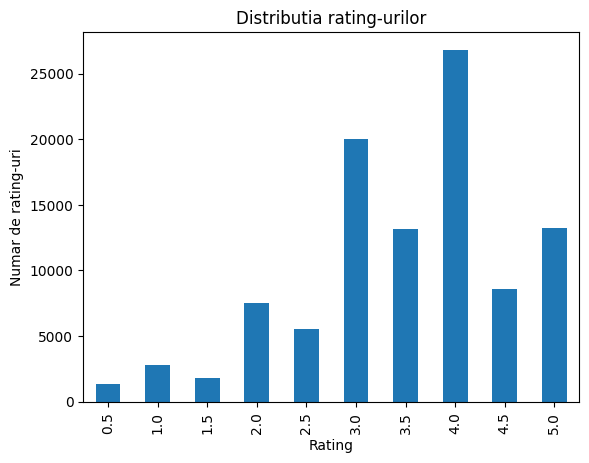

In [45]:
# Distributia rating-urilor (grafic)
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Rating')
plt.ylabel('Numar de rating-uri')
plt.title('Distributia rating-urilor')
plt.show()

In [46]:
# numarul valorilor lipsa
display(movies.isnull().sum())
display(ratings.isnull().sum())
display(tags.isnull().sum())

# numarul duplicatelor
display(movies.drop(columns=['genres_list']).duplicated().sum())
display(ratings.duplicated().sum())
display(tags.duplicated().sum())

movieId        0
title          0
genres         0
genres_list    0
dtype: int64

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

np.int64(0)

np.int64(0)

np.int64(0)